In [39]:
import yfinance as yf
import pandas as pd

stocks = [
    "RELIANCE.NS","TCS.NS","INFY.NS","HDFCBANK.NS","ICICIBANK.NS",
    "SBIN.NS","ITC.NS","LT.NS","BAJFINANCE.NS","HINDUNILVR.NS"
]

all_data = []

for stock in stocks:
    df = yf.download(stock, period="5y")

    # Remove MultiIndex columns
    df.columns = df.columns.get_level_values(0)

    df.reset_index(inplace=True)
    df["Stock"] = stock

    all_data.append(df)

final_df = pd.concat(all_data, ignore_index=True)
final_df.to_csv("stocks.csv", index=False)

print(final_df.head())

$RELIANCE.NS: possibly delisted; no price data found  (period=5y)
[*********************100%***********************]  1 of 1 completed

1 Failed download:
['RELIANCE.NS']: possibly delisted; no price data found  (period=5y)
$TCS.NS: possibly delisted; no price data found  (period=5y)
[*********************100%***********************]  1 of 1 completed

1 Failed download:
['TCS.NS']: possibly delisted; no price data found  (period=5y)
$INFY.NS: possibly delisted; no price data found  (period=5y)
[*********************100%***********************]  1 of 1 completed

1 Failed download:
['INFY.NS']: possibly delisted; no price data found  (period=5y)
$HDFCBANK.NS: possibly delisted; no price data found  (period=5y)
[*********************100%***********************]  1 of 1 completed

1 Failed download:
['HDFCBANK.NS']: possibly delisted; no price data found  (period=5y)
$ICICIBANK.NS: possibly delisted; no price data found  (period=5y)
[*********************100%***********************]  1 o

Empty DataFrame
Columns: [index, Adj Close, Close, High, Low, Open, Volume, Stock]
Index: []


In [40]:
final_df.duplicated().sum()

np.int64(0)

In [41]:
print(final_df["Stock"].value_counts())

Series([], Name: count, dtype: int64)


In [42]:
print(final_df.groupby("Stock").head(3))

Empty DataFrame
Columns: [index, Adj Close, Close, High, Low, Open, Volume, Stock]
Index: []


In [43]:
print(final_df.groupby("Stock").head(3))

Empty DataFrame
Columns: [index, Adj Close, Close, High, Low, Open, Volume, Stock]
Index: []


In [44]:
print(final_df["Stock"].unique())

[]


In [45]:
final_df.head()

Price,index,Adj Close,Close,High,Low,Open,Volume,Stock


In [46]:
final_df.duplicated().sum()

np.int64(0)

In [47]:
final_df.isnull().sum()

Price
index        0
Adj Close    0
Close        0
High         0
Low          0
Open         0
Volume       0
Stock        0
dtype: int64

In [48]:
final_df.shape

(0, 8)

In [49]:
final_df.describe()


Price,index,Adj Close,Close,High,Low,Open,Volume
count,0,0.0,0.0,0.0,0.0,0.0,0.0
mean,NaT,NaN,NaN,NaN,NaN,NaN,NaN
min,NaT,NaN,NaN,NaN,NaN,NaN,NaN
25%,NaT,NaN,NaN,NaN,NaN,NaN,NaN
50%,NaT,NaN,NaN,NaN,NaN,NaN,NaN
75%,NaT,NaN,NaN,NaN,NaN,NaN,NaN
max,NaT,NaN,NaN,NaN,NaN,NaN,NaN
std,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [50]:
final_df.duplicated().sum()

np.int64(0)

In [51]:
final_df.groupby("Stock")["Close"].mean()

Series([], Name: Close, dtype: float64)

In [52]:
final_df.groupby("Stock")["Volume"].mean()

Series([], Name: Volume, dtype: float64)

In [53]:
#best perfroming stock

final_df.groupby("Stock")["Close"].mean().sort_values(ascending=False)

Series([], Name: Close, dtype: float64)

In [54]:
#Daily Return 

final_df["Daily_Return"] = (
    final_df.groupby("Stock")["Close"]
    .pct_change() 
)



In [55]:
# Moving Average

final_df["MA_10"] = (
    final_df.groupby("Stock") ["Close"]
    .transform(lambda x:x.rolling(10).mean())
)
final_df

Price,index,Adj Close,Close,High,Low,Open,Volume,Stock,Daily_Return,MA_10


In [56]:
# 50 moving Average
final_df["MA_50"] = (
    final_df.groupby("Stock")["Close"]
    .transform(lambda x:x.rolling(50).mean())
)

In [57]:
#Top stocks by average return:

final_df.groupby("Stock")["Daily_Return"]\
  .mean()\
  .sort_values(ascending=False)

Series([], Name: Daily_Return, dtype: float64)

In [58]:
volatility = final_df.groupby("Stock")["Daily_Return"]\
               .std()\
               .sort_values(ascending=False)

print(volatility)

Series([], Name: Daily_Return, dtype: float64)


In [59]:
final_df["Price_Range"] = final_df["High"] - final_df["Low"]

In [60]:
final_df["Open_Close_Diff"] = final_df["Close"] - final_df["Open"]


In [61]:
final_df["Next_Close"] = final_df.groupby("Stock")["Close"].shift(-1)

In [62]:
final_df["Signal"] = (final_df["Next_Close"] > final_df["Close"]).astype(int)

In [63]:
final_df.dropna(inplace=True)

In [64]:
final_df["Volatility"] = (
    final_df.groupby("Stock")["Daily_Return"]
      .rolling(window=20)
      .std()
      .reset_index(level=0, drop=True)
)

In [65]:
pivot = final_df.pivot_table(
    values="Close",
    index="index",
    columns="Stock"
)

pivot.corr()

Stock
Stock


In [66]:
import matplotlib.pyplot as plt

for stock in final_df["Stock"].unique():
    temp = final_df[final_df["Stock"] == stock]
    plt.figure(figsize=(10,5))
    plt.plot(temp["index"], temp["Close"])
    plt.title(stock)
    plt.show()

MACHINE LEARNING PART 

In [67]:
# Scikit-Learn - Data Splitting
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score

# Scikit-Learn - Preprocessing
from sklearn.preprocessing import StandardScaler, LabelEncoder

# Scikit-Learn - Regression Models
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor

# Scikit-Learn - Classification Models
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

# Scikit-Learn - Regression Metrics
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Scikit-Learn - Classification Metrics
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

# Optional Advanced Models
# pip install xgboost
from xgboost import XGBRegressor, XGBClassifier

In [68]:
final_df.isnull().sum()

Price
index              0
Adj Close          0
Close              0
High               0
Low                0
Open               0
Volume             0
Stock              0
Daily_Return       0
MA_10              0
MA_50              0
Price_Range        0
Open_Close_Diff    0
Next_Close         0
Signal             0
Volatility         0
dtype: int64

In [69]:
final_df.dropna(inplace=True)

In [70]:
X = final_df[
    [
        "Open",
        "High",
        "Low",
        "Volume",
        "MA_10",
        "MA_50",
        "Daily_Return",
        "Volatility",
        "Price_Range",
        "Open_Close_Diff"
    ]
]

y_reg = final_df["Next_Close"]

In [71]:
print(final_df.columns.tolist())

['index', 'Adj Close', 'Close', 'High', 'Low', 'Open', 'Volume', 'Stock', 'Daily_Return', 'MA_10', 'MA_50', 'Price_Range', 'Open_Close_Diff', 'Next_Close', 'Signal', 'Volatility']


In [72]:
final_df["Signal"] = (final_df["Daily_Return"] > 0).astype(int)

In [73]:
y_cls = final_df["Signal"]

In [74]:
X_train_reg, X_test_reg, y_train_reg, y_test_reg = train_test_split(
    X, y_reg, test_size=0.2, random_state=42
)

ValueError: With n_samples=0, test_size=0.2 and train_size=None, the resulting train set will be empty. Adjust any of the aforementioned parameters.

In [ ]:
X_train_cls, X_test_cls, y_train_cls, y_test_cls = train_test_split(
    X, y_cls, test_size=0.2, random_state=42
)

In [ ]:
lr = LinearRegression()
lr.fit(X_train_reg, y_train_reg)

pred_lr = lr.predict(X_test_reg)

print("R2 Score:", r2_score(y_test_reg, pred_lr))

R2 Score: 0.9993853663012386


In [ ]:
rf_reg = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

rf_reg.fit(X_train_reg, y_train_reg)

pred_rf = rf_reg.predict(X_test_reg)

print("R2 Score:", r2_score(y_test_reg, pred_rf))

R2 Score: 0.9992590460925226


In [ ]:
log = LogisticRegression(max_iter=1000)

log.fit(X_train_cls, y_train_cls)

pred_log = log.predict(X_test_cls)

print("Accuracy:", accuracy_score(y_test_cls, pred_log))

Accuracy: 0.8353293413173652


In [ ]:
rf_cls = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf_cls.fit(X_train_cls, y_train_cls)

pred_rf_cls = rf_cls.predict(X_test_cls)

print("Accuracy:", accuracy_score(y_test_cls, pred_rf_cls))

Accuracy: 0.9995722840034217


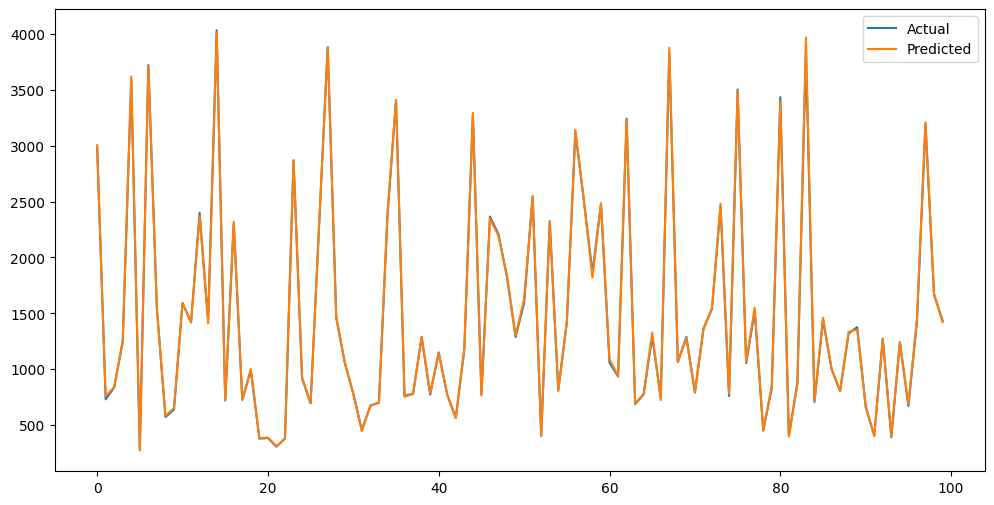

In [ ]:
plt.figure(figsize=(12,6))
plt.plot(y_test_reg.values[:100], label="Actual")
plt.plot(pred_rf[:100], label="Predicted")
plt.legend()
plt.show()

In [ ]:
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor

models = {
    "Linear Regression": LinearRegression(),
    "Random Forest": RandomForestRegressor(random_state=42),
    "Gradient Boosting": GradientBoostingRegressor(random_state=42)
}

In [ ]:
results = []

for name, model in models.items():
    
    model.fit(X_train_reg, y_train_reg)
    
    pred = model.predict(X_test_reg)
    
    r2 = r2_score(y_test_reg, pred)
    mae = mean_absolute_error(y_test_reg, pred)
    
    results.append([name, r2, mae])

results_df = pd.DataFrame(
    results,
    columns=["Model", "R2 Score", "MAE"]
)

print(results_df)

               Model  R2 Score        MAE
0  Linear Regression  0.999385  15.005675
1      Random Forest  0.999259  16.650355
2  Gradient Boosting  0.999236  17.437748


In [ ]:
rf = RandomForestRegressor(random_state=42)
rf.fit(X_train_reg, y_train_reg)

importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf.feature_importances_
})

print(
    importance.sort_values(
        by="Importance",
        ascending=False
    )
)

           Feature  Importance
2              Low    0.570393
1             High    0.418223
0             Open    0.010765
4            MA_10    0.000122
9  Open_Close_Diff    0.000115
6     Daily_Return    0.000109
5            MA_50    0.000090
7       Volatility    0.000066
3           Volume    0.000060
8      Price_Range    0.000057


In [ ]:
rf_cls = RandomForestClassifier(random_state=42)

rf_cls.fit(X_train_cls, y_train_cls)

pred_cls = rf_cls.predict(X_test_cls)

In [ ]:
print(
    classification_report(
        y_test_cls,
        pred_cls
    )
)

              precision    recall  f1-score   support

           0       1.00      1.00      1.00      1197
           1       1.00      1.00      1.00      1141

    accuracy                           1.00      2338
   macro avg       1.00      1.00      1.00      2338
weighted avg       1.00      1.00      1.00      2338



In [ ]:
print(
    accuracy_score(
        y_test_cls,
        pred_cls
    )
)

0.9995722840034217


In [ ]:
import joblib

joblib.dump(
    rf,
    "stock_prediction_model.pkl"
)

['stock_prediction_model.pkl']

In [ ]:
model = joblib.load(
    "stock_prediction_model.pkl"
)

NameError: name 'joblib' is not defined

In [ ]:
final_df.columns

Index(['index', 'Close', 'High', 'Low', 'Open', 'Volume', 'Stock',
       'Daily_Return', 'MA_10', 'MA_50', 'Price_Range', 'Open_Close_Diff',
       'Next_Close', 'Signal', 'Volatility'],
      dtype='object', name='Price')

In [ ]:
final_df.to_csv("final_df.csv", index=False)